In [16]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

In [ ]:
# Get Nowdays NVDA info
def get_nvidia_quote() -> dict:
    ticker = yf.Ticker("NVDA") #ticker.info로 해당 주식의 정보 확인 가능(주소, 기업소개, ir공시 사이트, 직원수, 임원 명단 등)
    history = ticker.history(period="5d", interval="1d")

    if history.empty:
        raise RuntimeError("No price data returned from Yahoo Finance.")

    latest = history.tail(1).iloc[0]
    return {
        "symbol": "NVDA",
        "date": history.tail(1).index[0].strftime("%Y-%m-%d"),
        "open": float(latest["Open"]),
        "high": float(latest["High"]),
        "low": float(latest["Low"]),
        "close": float(latest["Close"]),
        "volume": int(latest["Volume"]),
    }


In [14]:
quote = get_nvidia_quote()

print(f"Symbol : {quote['symbol']}")
print(f"Date   : {quote['date']}")
print(f"Open   : {quote['open']:.2f}")
print(f"High   : {quote['high']:.2f}")
print(f"Low    : {quote['low']:.2f}")
print(f"Close  : {quote['close']:.2f}")
print(f"Volume : {quote['volume']:,}")

Symbol : NVDA
Date   : 2026-07-02
Open   : 197.14
High   : 200.06
Low    : 192.35
Close  : 194.83
Volume : 142,385,500


In [31]:
month = float(input('Enter the month what you want to get the Ticker data (ex: 5): '))
end_date = datetime.now()

start_date = end_date - timedelta(days = 30*month)
end_date = end_date.strftime("%Y-%m-%d")
start_data = start_date.strftime("%Y-%m-%d")

In [44]:
df = yf.download(yf.Ticker(input('Enter the Ticker you want to get the data (ex: NVDA): ')).info['symbol'], start=start_date, end=end_date, interval='1d').sort_index(ascending=True)

[*********************100%***********************]  1 of 1 completed


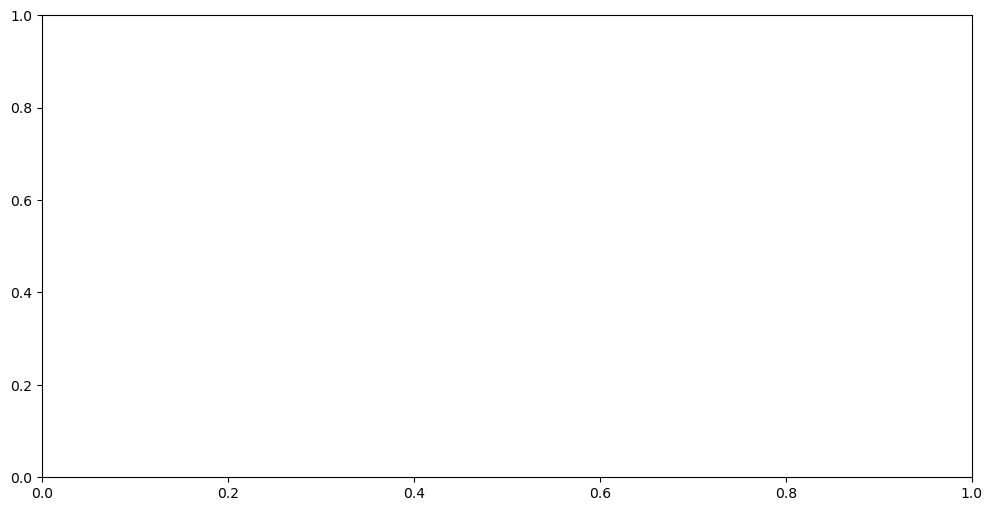

In [46]:
import matplotlib.pyplot as plt
%matplotlib inline
# 2. 시각화를 위해 인덱스(날짜)를 숫자로 다루기 편하게 리셋
df_reset = df.reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

In [55]:
r = df_reset.iloc[0]
type(r['Close'].item())

numpy.float64

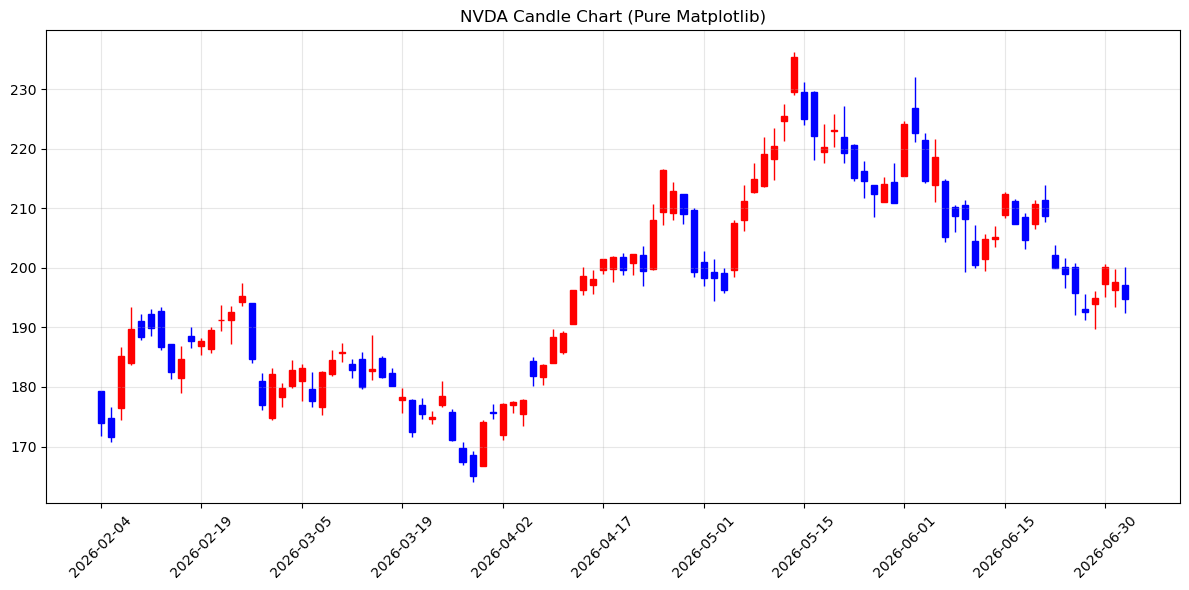

In [57]:
import matplotlib.pyplot as plt
%matplotlib inline

# 2. 시각화를 위해 인덱스(날짜)를 숫자로 다루기 편하게 리셋
df_reset = df.reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

# 3. 데이터 한 줄씩 돌며 캔들 그리기
for i in range(len(df_reset)):
    row = df_reset.iloc[i]
    
    # 양봉(종가 > 시가)이면 red(또는 빨간색), 음봉이면 blue(또는 파란색)
    if row['Close'].item() >= row['Open'].item():
        color = 'red'
        bottom = row['Open'].item()
        height = row['Close'].item() - row['Open'].item()
    else:
        color = 'blue'
        bottom = row['Close'].item()
        height = row['Open'].item() - row['Close'].item()
        
    # 고가 - 저가 꼬리 그리기 (Line)
    ax.vlines(i, row['Low'].item(), row['High'].item(), color=color, linewidth=1)
    # 시가 - 종가 몸통 그리기 (Rectangle)
    ax.add_patch(plt.Rectangle((i - 0.3, bottom), 0.6, height, color=color))

# 4. X축 날짜 라벨 설정
ax.set_xticks(range(0, len(df_reset), max(1, len(df_reset)//10)))
ax.set_xticklabels(df_reset['Date'].dt.strftime('%Y-%m-%d').iloc[::max(1, len(df_reset)//10)], rotation=45)

plt.title("NVDA Candle Chart (Pure Matplotlib)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()